## Goal

Here, we finally try to create a credible interval (CI) for the compartment transitions, getting a confidence estimate on the exact position of the transitions.

## Method: bootstrapping

We will use bootstrapping to resample the 'z' variable from the trace of a model (across chains and draws), and calculate the mean each time.

First, we use the regular bootstrapping that is simpler, but only does pointwise confidence intervals, which may be too narrow. Then, we consider a functional bootstrap, resampling an entire E1 curve, keeping the spatial dependency.

### The Problem

Standard bootstrap treats each genomic position independently, ignoring spatial correlation in our MCMC samples. This gives artificially narrow confidence intervals that don't reflect realistic uncertainty about transition regions.

### Bayesian bootstrapping (Rubin, 1981):

- Treats the empirical sample (posterior draws of z) as the support of the distribution.
- Assigns Dirichlet-distributed random weights to the posterior samples.
- We get a weighted posterior mean — this gives us a distribution over means even if the variable is binary.
- This allows us to construct credible intervals over the mean of a binary variable.


## Load a trace

In [1]:
import arviz as az

name = "T_N_HN_10"
trace = az.from_netcdf(f"../results/traces/{name}_z_trace.nc")

In [2]:
trace.posterior

<xarray.Dataset> Size: 491MB
Dimensions:      (chain: 7, draw: 1500, pos: 1460, mu_dim_0: 2, sigma_dim_0: 2)
Coordinates:
  * chain        (chain) int64 56B 0 1 2 3 4 5 6
  * draw         (draw) int64 12kB 0 1 2 3 4 5 ... 1494 1495 1496 1497 1498 1499
  * pos          (pos) int64 12kB 24 25 26 27 28 29 ... 1617 1618 1619 1620 1621
  * mu_dim_0     (mu_dim_0) int64 16B 0 1
  * sigma_dim_0  (sigma_dim_0) int64 16B 0 1
Data variables:
    eps          (chain, draw, pos) float64 123MB ...
    z            (chain, draw, pos) int64 123MB ...
    mu           (chain, draw, mu_dim_0) float64 168kB ...
    sigma        (chain, draw, sigma_dim_0) float64 168kB ...
    grw_sigma    (chain, draw) float64 84kB ...
    logit_w      (chain, draw, pos) float64 123MB ...
    w            (chain, draw, pos) float64 123MB ...
Attributes:
    created_at:                 2025-07-02T10:07:48.044236+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.22.0
    sampling_time:              1695.637930393219
    tuning_steps:               1500

First, we will stack the chains and draws per `pos`, so we have `chains*draws` samples per position. Also, as PyMC assigns the default `dtype` (int64) even though `z` is binary, we will convert it to `int8` to save memory (increase efficiency). 

In [3]:
import numpy as np

stacked = trace.posterior.z.stack(
    sample=["chain", "draw"])
stacked.data = stacked.data.astype(np.int8)
stacked

<xarray.DataArray 'z' (pos: 1460, sample: 10500)> Size: 15MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1460, 10500), dtype=int8)
Coordinates:
  * pos      (pos) int64 12kB 24 25 26 27 28 29 ... 1617 1618 1619 1620 1621
  * sample   (sample) object 84kB MultiIndex
  * chain    (sample) int64 84kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 84kB 0 1 2 3 4 5 6 ... 1494 1495 1496 1497 1498 1499

## Regular Bootstrapping

Then, we define a wrapper function to bootstrap the mean for each position. `scipy.stats.bootstrap` is vectorized and is therefore very efficient for resampling each position. However, it will allocate an array of size `n_resamples * n_samples * pos` (1.2 TB for 10,000 resamples), unless we use the `batch`, where it allocates `batch * n_samples * pos` arrays in memory at at time. Here, we define a function to compute the batch value to maximally allocate a 16Gb array in memory at a time.

In [4]:
from scipy.stats import bootstrap
import numpy as np

def bootstrap_mean(data, **kwargs):
    """Compute the confidence interval for the mean."""
    res = bootstrap(
        (data,),
        statistic = np.mean,
        vectorized = True,
        axis=1,
        method = "basic",
        **kwargs
    )

    return res


def compute_batch(arr, max_bytes=16 * 1024**3):
    """
    Compute max batch size so that each batch of resamples fits in max_bytes.
    """
    # Elements in a single resample
    n_elements = arr.shape[0] * arr.shape[1]
    # Bytes per element
    bytes_per_elem = np.dtype(arr.dtype).itemsize
    # Bytes per resample
    bytes_per_resample = n_elements * bytes_per_elem
    # Max batches
    batch = max(1, int(max_bytes // bytes_per_resample))
    return batch



In [5]:
compute_batch(stacked.values)

1120

Then, try it out:

In [6]:
bootstrap_results = bootstrap_mean(
    stacked, **{
        "confidence_level": 0.99,
        "n_resamples": 10000,
        "batch": compute_batch(stacked.values)
        }
    )

bootstrap_results

BootstrapResult(confidence_interval=ConfidenceInterval(low=array([ 1.90000000e-04, -9.52380952e-05,  1.90476190e-04, ...,
        5.92380952e-02,  7.23804762e-02,  2.95238095e-03], shape=(1460,)), high=array([0.00171429, 0.00095238, 0.00180952, ..., 0.07161905, 0.08561905,
       0.00638095], shape=(1460,))), bootstrap_distribution=array([[0.00190476, 0.00047619, 0.00133333, ..., 0.00152381, 0.00133333,
        0.00190476],
       [0.00038095, 0.00028571, 0.00047619, ..., 0.00038095, 0.0007619 ,
        0.00038095],
       [0.00057143, 0.00152381, 0.00104762, ..., 0.00152381, 0.0012381 ,
        0.00057143],
       ...,
       [0.06361905, 0.062     , 0.0672381 , ..., 0.066     , 0.062     ,
        0.06571429],
       [0.07790476, 0.07704762, 0.07809524, ..., 0.08057143, 0.07819048,
        0.07666667],
       [0.00504762, 0.00447619, 0.00390476, ..., 0.00333333, 0.00419048,
        0.00533333]], shape=(1460, 10000)), standard_error=array([0.00031544, 0.00021203, 0.00031514, ..., 0.00

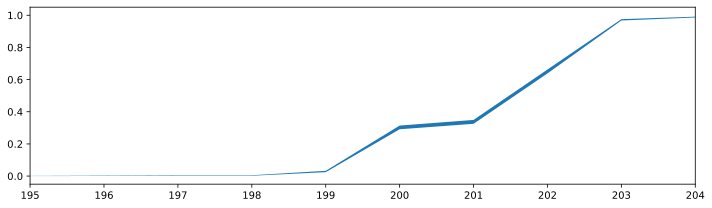

In [7]:
import matplotlib.pyplot as plt
import matplotlib_inline 

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

x = stacked.pos.values
lower = bootstrap_results.confidence_interval.low
upper = bootstrap_results.confidence_interval.high

fig, ax = plt.subplots(figsize=(10, 3))

ax.fill_between(
    x,
    lower,
    upper,
    label="95% CI",
    # ec = "black",
)
ax.set_xlim(195,204)
plt.tight_layout()

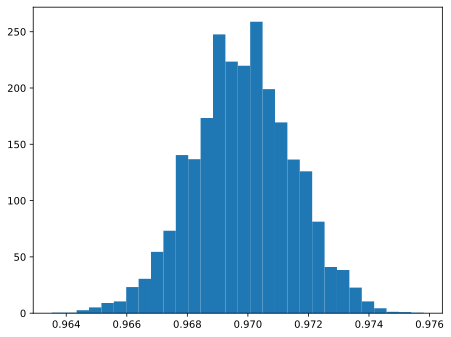

In [8]:
plt.hist(bootstrap_results.bootstrap_distribution[1000], density=True, bins=30)
plt.tight_layout()

In [9]:
bootstrap_99 = bootstrap_mean(
    stacked, **{
    "n_resamples": 0,
    #"batch": compute_batch(stacked.values),
    "confidence_level": 0.99,
    "bootstrap_result": bootstrap_results
    }
    )

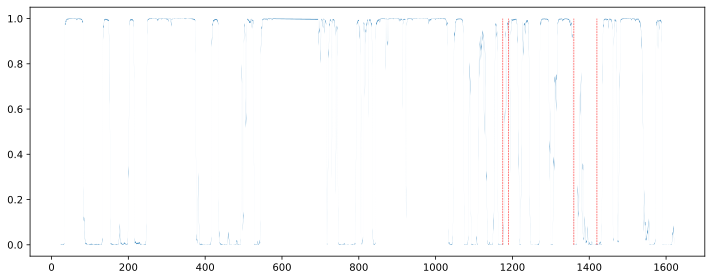

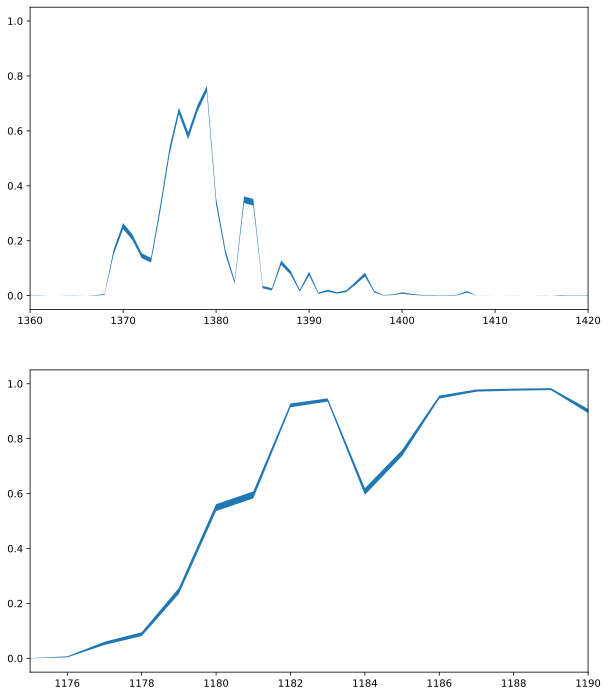

In [10]:
lower_99 = bootstrap_99.confidence_interval.low
upper_99 = bootstrap_99.confidence_interval.high

fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(
    x,
    lower_99,
    upper_99, 
)
zooms = [(1360,1420), (1175, 1190)]

ax.vlines(zooms, 0, 1, color="red", linestyle="--", linewidth=0.5)

f,axs = plt.subplots(len(zooms), figsize = (10, 6*len(zooms)))

for i,zoom in enumerate(zooms):
    zax = axs[i]
    zax.fill_between(
        x,
        lower_99,
        upper_99,
    )
    zax.set_xlim(zoom)



# ax[1].fill_between(
#     x,
#     lower_99,
#     upper_99, 
# )
# ax[1].set_xlim(zoom)

fig.tight_layout()
plt.show()

## Bayesian bootstrapping

### Bayesian bootstrapping (Rubin, 1981):

- Treats the empirical sample (posterior draws of z) as the support of the distribution.
- Assigns Dirichlet-distributed random weights to the posterior samples.
- We get a weighted posterior mean — this gives us a distribution over means even if the variable is binary.
- This allows us to construct credible intervals over the mean of a binary variable.

**We want**

A Bayesian bootstrap distribution over the mean of `z` to get posterior credible intervals over $\mathbb{E}[z]$, even though it is binary.

**Initially** we apply the spatially independent version

**Then** we will apply the spatially dependent version, which is more complex but gives better results.

In [14]:
# We use the flattened samples directly, just renaming the variable

z_flat = stacked

Now we make a function to compute the Bayesian bootstrap mean

In [16]:
import numpy as np
import xarray as xr

def bayesian_bootstrap_mean_xr(z_flat, n_boot=1000, seed=None):
    """
    Compute the Bayesian bootstrap mean for the flattened samples.
    """

    rng = np.random.default_rng(seed)
    n_samples = z_flat.sizes["sample"]

    # Dirichlet weights: (shape: [n_boot, n_samples])
    weights = rng.dirichlet(np.ones(n_samples), size=n_boot)

    # xarray for broadcasting
    w_da = xr.DataArray(weights, dims=["bb_sample", "sample"])

    # Weighted means per location
    weighted_means = (w_da @ z_flat) # (shape: [n_boot, location]) 

    return weighted_means


Now we try to compute the BB credible intervals

In [38]:
z_bb = bayesian_bootstrap_mean_xr(z_flat, n_boot=10000, seed=42)


In [39]:

z_mean = z_bb.mean(dim="bb_sample")
z_ci = z_bb.quantile([0.01, 0.99], dim="bb_sample")
z_ci_upper = z_ci.sel(quantile=0.99)
z_ci_lower = z_ci.sel(quantile=0.01)

z_mean

<xarray.DataArray (pos: 1460)> Size: 12kB
array([0.00104497, 0.00047806, 0.00104636, ..., 0.06554028, 0.07906991,
       0.00476401], shape=(1460,))
Coordinates:
  * pos      (pos) int64 12kB 24 25 26 27 28 29 ... 1617 1618 1619 1620 1621

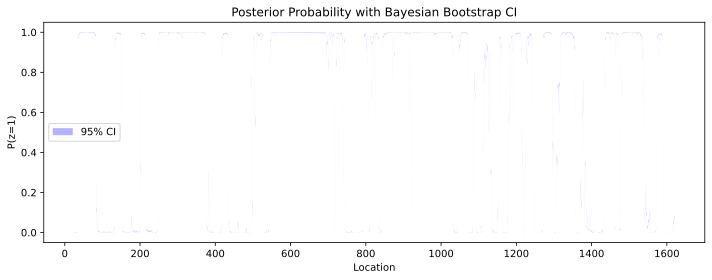

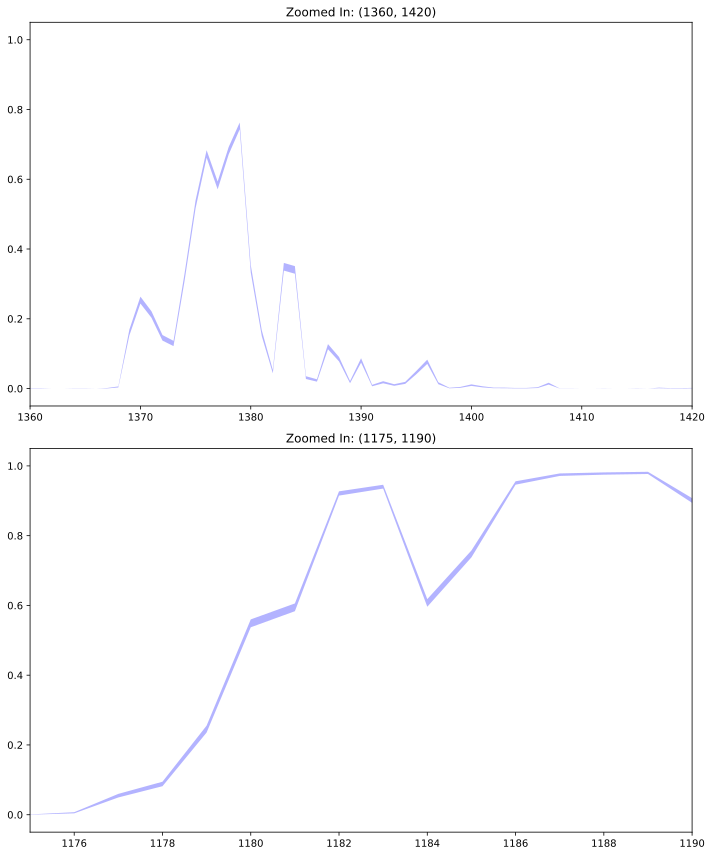

In [40]:
import matplotlib.pyplot as plt

x = z_mean["pos"]

f, ax = plt.subplots(figsize=(10, 4))

#ax.plot(x, z_mean, label="Posterior mean", color="black")
ax.fill_between(
    x,
    z_ci_lower,
    z_ci_upper,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec = 'None'
)

plt.ylabel("P(z=1)")
plt.xlabel("Location")
plt.legend()
plt.title("Posterior Probability with Bayesian Bootstrap CI")
plt.tight_layout()
plt.show()

zooms = [(1360,1420), (1175, 1190)]

f, axs = plt.subplots(len(zooms), figsize=(10, 6*len(zooms)))
for i, zoom in enumerate(zooms):
    zax = axs[i]
    zax.fill_between(
        x,
        z_ci_lower,
        z_ci_upper,
        alpha=0.3,
        color="blue",
        ec='None'
    )
    zax.set_xlim(zoom)
    zax.set_title(f"Zoomed In: {zoom}")
f.tight_layout()
plt.show()


## Functional bootstrapping

Treating each posterior draw (curve) as a sample, then resample across

In [25]:
import numpy as np

trace = az.from_netcdf(f"../results/traces/N_N_HN_z_trace.nc")

trace.posterior.z.stack(
    sample=["chain", "draw"]
).values

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1438, 10500))

In [38]:
# stack samples (chain, draw) into one axis called "sample"
z_stack = trace.posterior["z"].stack(sample=("chain", "draw"))  # shape: (pos=1460, sample=10500)

b = 10000

# sample draws
sample_idx = np.random.randint(0, z_stack.shape[1], size=b)

# resample *entire posterior draws*
z_resamples = z_stack[:, sample_idx]  # shape (1460, b)



In [39]:
z_resamples

<xarray.DataArray 'z' (pos: 1438, sample: 10000)> Size: 115MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1438, 10000))
Coordinates:
  * pos      (pos) int64 12kB 24 25 26 27 28 29 ... 1615 1618 1619 1620 1621
  * sample   (sample) object 80kB MultiIndex
  * chain    (sample) int64 80kB 3 5 0 4 2 2 3 0 2 6 6 ... 5 2 4 4 1 6 3 6 2 5 4
  * draw     (sample) int64 80kB 1250 418 238 1499 843 ... 1123 958 441 329 315

In [40]:
z_bootmean = z_resamples.mean(dim="sample")  # shape (1460,)

# Compute CI
z_ci = z_resamples.quantile([0.05, 0.95], dim="sample")  # shape (2, 1460)
z_ci_upper = z_ci.sel(quantile=0.05)  # shape (1460,)
z_ci_lower = z_ci.sel(quantile=0.95)  # shape (1460,)




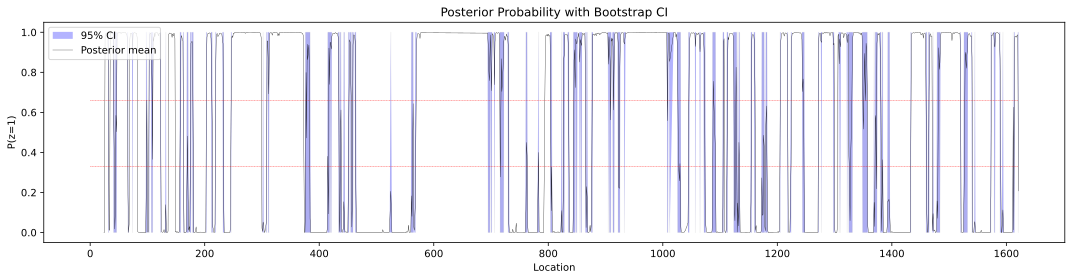

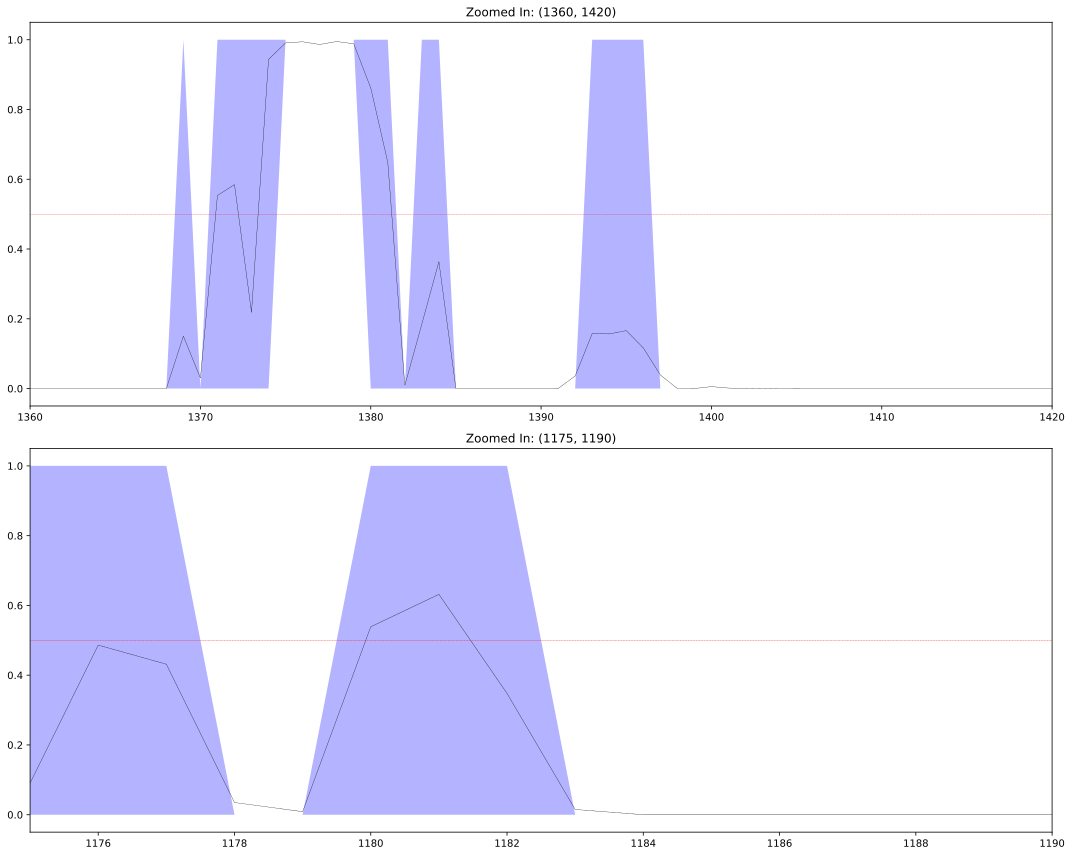

In [41]:
import matplotlib.pyplot as plt

# Set matplotlib to display SVG format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

x = z_stack["pos"]

f, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(
    x,
    z_ci_lower,
    z_ci_upper,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None'
)

x_grey = x.copy()
x_grey = x_grey.where(
    ~((z_ci_lower < 1/3) & (z_ci_upper < 1/3) | (z_ci_lower > 2/3) & (z_ci_upper > 2/3)),
    np.nan
)

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

ax.plot(x, z_bootmean, label="Posterior mean", color="black", linewidth=0.3)

# Plot the 0.5 line
ax.hlines([0.66, 0.33], 0, max(x), color="red", linestyle="--", linewidth=0.3)

plt.ylabel("P(z=1)")
plt.xlabel("Location")
plt.legend(loc='upper left')
plt.title("Posterior Probability with Bootstrap CI")
plt.tight_layout()
plt.show()

zooms = [(1360,1420), (1175, 1190)]

f, axs = plt.subplots(len(zooms), figsize=(15, 6*len(zooms)))

for i, zoom in enumerate(zooms):
    zax = axs[i]
    zax.fill_between(
        x,
        z_ci_lower,
        z_ci_upper,
        alpha=0.3,
        color="blue",
        ec='None'
    )
    zax.plot(x, z_bootmean, label="Posterior mean", color="black", linewidth=0.3)
    zax.axhline(0.5, color="red", linestyle="--", linewidth=0.3)
    zax.set_xlim(zoom)
    zax.set_title(f"Zoomed In: {zoom}")

f.tight_layout()
plt.show()

### Nested functional bootstrapping

In [ ]:
import numpy as np

def functional_bootstrap_binary(z_stack, B_outer=1000, B_inner=100, ci=(2.5, 97.5)):
    """
    Functional bootstrap for binary latent variable z.
    
    Parameters
    ----------
    z_stack : np.ndarray
        Shape (pos, draws) array of posterior samples (0/1) for z.
    B_outer : int
        Number of outer bootstrap replicates (whole-curve resamples).
    B_inner : int
        Number of posterior draws per outer replicate to average over.
    ci : tuple
        Lower/upper percentiles for confidence bands.

    Returns
    -------
    mean_curve : np.ndarray
        Mean P(z=1) per position across outer replicates.
    lower : np.ndarray
        Lower CI bound per position.
    upper : np.ndarray
        Upper CI bound per position.
    """
    pos, draws = z_stack.shape

    # Random index selection for outer × inner resampling
    sample_sets = np.random.randint(0, draws, size=(B_outer, B_inner))

    # Means over inner set for each outer replicate
    z_means = np.empty((pos, B_outer))
    for i in range(B_outer):
        z_means[:, i] = np.mean(z_stack[:, sample_sets[i, :]], axis=1)

    # Mean and CI across outer replicates
    mean_curve = np.mean(z_means, axis=1)
    lower = np.percentile(z_means, ci[0], axis=1)
    upper = np.percentile(z_means, ci[1], axis=1)

    return mean_curve, lower, upper


In [ ]:
# This is the actual bootstrapping

mean_curve, lower, upper = functional_bootstrap_binary(z_stack, 10000, 100, (1, 99))



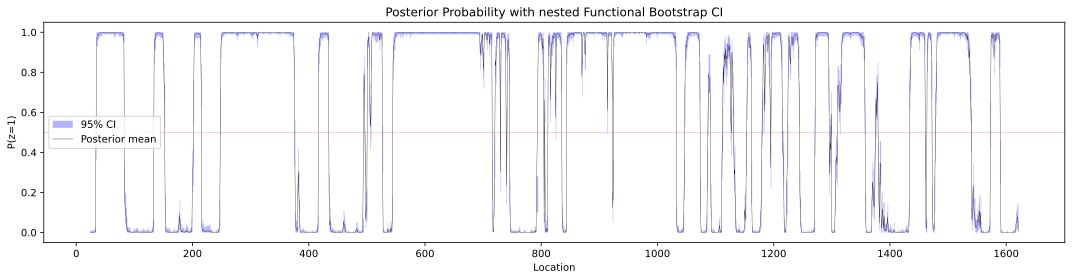

In [ ]:
# Plotting the functional bootstrap results

import matplotlib.pyplot as plt

f, ax = plt.subplots(figsize=(15, 4))
ax.fill_between(
    x,
    lower,
    upper,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None',
    step="post"
)
ax.plot(x, mean_curve, label="Posterior mean", color="black", linewidth=0.3)

# Plot the 0.5 line
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.3)

plt.ylabel("P(z=1)")
plt.xlabel("Location")
plt.legend()
plt.title("Posterior Probability with nested Functional Bootstrap CI")
plt.tight_layout()

## Try with the hi-res


In [5]:
hires_path = "../results/traces/07_hi_res_z_trace.nc" 
hires_trace = az.from_netcdf(hires_path)

hires_stacked = hires_trace.posterior.z.stack(
    sample=["chain", "draw"])
hires_stacked.data = hires_stacked.data.astype(np.int8)
hires_x = hires_stacked.pos.values
hires_mean_curve, hires_lower, hires_upper = functional_bootstrap_binary(
    hires_stacked.values, 10000, 100, (1, 99)
)


NameError: name 'np' is not defined

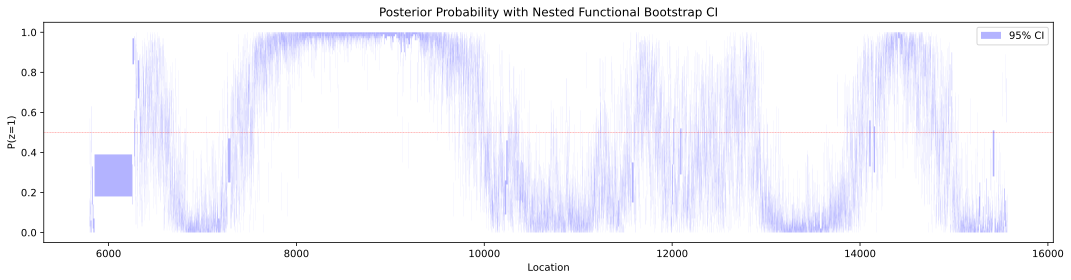

In [50]:
# plot the high-resolution functional bootstrap results

f, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(
    hires_x,
    hires_lower,
    hires_upper,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None',
    step="post"
)
#ax.plot(hires_x, hires_mean_curve, label="Posterior mean", color="black", linewidth=0.3)
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.3)

plt.ylabel("P(z=1)")
plt.xlabel("Location")
plt.legend()
plt.title("Posterior Probability with Nested Functional Bootstrap CI")
plt.tight_layout()
